# Exploratory Data Analysis (EDA) on Student Performance Dataset

## 1. Project Overview
**Objective:**  
The goal of this project is to explore and analyze a student performance dataset to identify patterns, trends, and factors that may influence students' academic outcomes.  
Through exploratory data analysis (EDA), this project aims to provide meaningful insights using basic statistical analysis and data visualization techniques.

This project is part of my learning journey in data analysis and focuses on applying Python libraries such as pandas and matplotlib to real-world data.

---

## 2. Research Questions
This project aims to answer the following questions:

1. What is the distribution of students math scores?   
2. Are there noticeable differences in math performance between male and Female students?  
3. Is there a reading and writing performance?

4.  What genral patterns can be observed student performance to better understand?




---

## 3. Dataset Description
**Source:** Kaggle  
**Dataset Name:** Students Performance in Exams  

The dataset contains students’ scores in multiple subjects along with several demographic and study-related attributes.  
It is used to explore potential relationships between different factors and academic performance.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تحسين شكل الرسومات
plt.style.use('seaborn-v0_8')

# Load Dataset

In [44]:
import pandas as pd

df = pd.read_csv('/content/StudentsPerformance.csv', sep=',', encoding='latin1', quotechar='"', engine='python')
df.head()

,"gender,""race/ethnicity"",""parental level of education"",""lunch"",""test preparation course"",""math score"",""reading score"",""writing score"""
0,"female,""group B"",""bachelor's degree"",""standard..."
1,"female,""group C"",""some college"",""standard"",""co..."
2,"female,""group B"",""master's degree"",""standard"",..."
3,"male,""group A"",""associate's degree"",""free/redu..."
4,"male,""group C"",""some college"",""standard"",""none..."


In [45]:
!ls /content
!ls /content/sample_data


sample_data  StudentsPerformance.csv
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


# Data Cleaning

In [46]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                --------------  ----- 
 0   gender,"race/ethnicity","parental level of education","lunch","test preparation course","math score","reading score","writing score"  1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [48]:
# Access the content of the single column using its actual name (the first column name in the DataFrame)
data_series = df[df.columns[0]]

# Split each string in the series by comma into new columns
split_df = data_series.str.split(',', expand=True)

# The first row of `split_df` now contains the actual column headers
split_df.columns = split_df.iloc[0]

# Remove the header row from the DataFrame and reset the index
df = split_df[1:].reset_index(drop=True)
df.head()

,female,"""group B""","""bachelor's degree""","""standard""","""none""","""72""","""72""","""74"""
0,female,"""group C""","""some college""","""standard""","""completed""","""69""","""90""","""88"""
1,female,"""group B""","""master's degree""","""standard""","""none""","""90""","""95""","""93"""
2,male,"""group A""","""associate's degree""","""free/reduced""","""none""","""47""","""57""","""44"""
3,male,"""group C""","""some college""","""standard""","""none""","""76""","""78""","""75"""
4,female,"""group B""","""associate's degree""","""standard""","""none""","""71""","""83""","""78"""


In [49]:
df.columns = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education',
    'lunch',
    'test_preparation_course',
    'math_score',
    'reading_score',
    'writing_score'
]


In [50]:
df.describe()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
count,999,999,999,999,999,999,999,999
unique,2,5,6,2,2,81,72,77
top,female,"""group C""","""some college""","""standard""","""none""","""65""","""74""","""74"""
freq,517,319,226,644,641,36,33,34


In [52]:

df.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


In [53]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group C,some college,standard,completed,69,90,88
1,female,group B,master's degree,standard,none,90,95,93
2,male,group A,associate's degree,free/reduced,none,47,57,44
3,male,group C,some college,standard,none,76,78,75
4,female,group B,associate's degree,standard,none,71,83,78


In [54]:
df['math_score'] = df['math_score'].astype(int)
df['reading_score'] = df['reading_score'].astype(int)
df['writing_score'] = df['writing_score'].astype(int)


In [55]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       999 non-null    object
 1   race_ethnicity               999 non-null    object
 2   parental_level_of_education  999 non-null    object
 3   lunch                        999 non-null    object
 4   test_preparation_course      999 non-null    object
 5   math_score                   999 non-null    int64 
 6   reading_score                999 non-null    int64 
 7   writing_score                999 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group C,some college,standard,completed,69,90,88
1,female,group B,master's degree,standard,none,90,95,93
2,male,group A,associate's degree,free/reduced,none,47,57,44
3,male,group C,some college,standard,none,76,78,75
4,female,group B,associate's degree,standard,none,71,83,78


# Exploratory Data Analysis

In [56]:
df.columns


Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [57]:
# متوسط الدرجات
df[['math_score', 'reading_score', 'writing_score']].mean()

,0
math_score,66.083083
reading_score,69.166166
writing_score,68.048048


In [58]:
# مقارنة حسب الجنس
df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.617021,72.609284,72.464217
male,68.728216,65.473029,63.311203


# Visualization

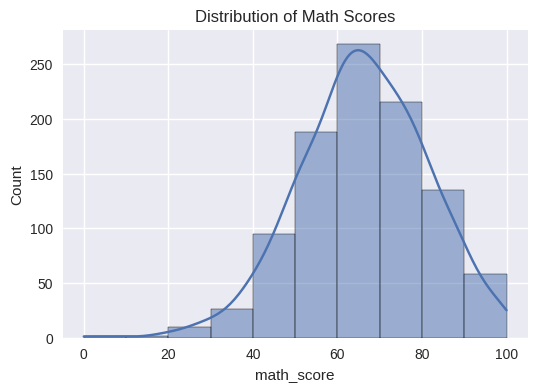

In [59]:
plt.figure(figsize=(6,4))
sns.histplot(df['math_score'], bins=10, kde=True)
plt.title('Distribution of Math Scores')
plt.show()

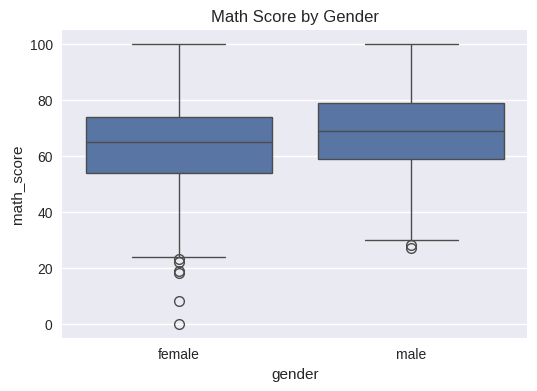

In [60]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='math_score', data=df)
plt.title('Math Score by Gender')
plt.show()

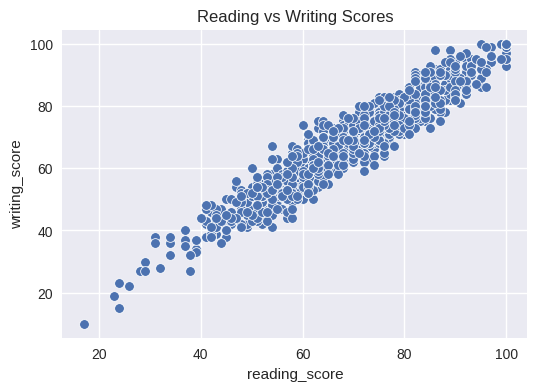

In [61]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='reading_score', y='writing_score', data=df)
plt.title('Reading vs Writing Scores')
plt.show()


# **Key Insights**

*   The distribution of math scores shows that most students score between 60 and 80, with a noticeable peak around the mid‑60s. This suggests that overall math performance is centered around an average level, with relatively few students scoring extremely low or extremely high.

*   The box plot shows that male students have a slightly higher median math score compared to female students. Score variability is also wider among males, while females display a more concentrated range with a few lower outliers. Overall, the difference between genders is small, suggesting that gender has only a limited impact on math performance.


*  The scatter plot shows a strong positive relationship between reading and writing scores. As reading scores increase, writing scores tend to increase as well, and the points form a clear upward trend. This suggests that students who perform well in reading are very likely to perform well in writing, indicating that both skills develop together and rely on similar language abilities.




# **Conclusion**

The analysis of the Students Performance dataset shows clear patterns in how students perform across math, reading, and writing. Math scores are centered around an average range, gender differences in math performance are small, and reading and writing scores are strongly connected. These insights highlight that while some demographic factors may influence performance, core academic skills such as reading and writing tend to develop together. This provides a solid foundation for deeper analysis or building predictive models in future work.

